### Set Up

In [2]:
from collections import OrderedDict
import torch
import torch.nn as nn
from pathlib import Path
import pandas as pd
import tarfile
import urllib.request
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [3]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
device

'cuda'

### Load Dataset

In [4]:
def load_housing_data():
    tarball_path = Path("datasets/housing.tgz")
    if not tarball_path.is_file():
        Path("datasets").mkdir(parents=True, exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url, tarball_path)
    with tarfile.open(tarball_path) as housing_tarball:
        housing_tarball.extractall(path="datasets", filter="data")
    return pd.read_csv(Path("datasets/housing/housing.csv"))

In [5]:
housing_full = load_housing_data()

### Data Processing

In [6]:
housing_full = housing_full.drop("ocean_proximity", axis=1)

In [7]:
imputer = SimpleImputer(strategy="median")
imputer.fit(housing_full)

,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','median_house_value']"
indicator_ indicator_: :class:`~sklearn.impute.MissingIndicator`Indicator used to add binary indicators for missing values.`None` if `add_indicator=False`.,NoneType,None
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
"statistics_ statistics_: array of shape (n_features,)The imputation fill value for each feature.Computing statistics can result in `np.nan` values.During :meth:`transform`, features corresponding to `np.nan`statistics will be discarded.","ndarray[float64](9,)","[ -118.49, 34.26, 29. ,..., 409. , 3.53,179700. ]"


In [8]:
X = imputer.transform(housing_full)
housing_full = pd.DataFrame(X, columns=housing_full.columns, index=housing_full.index)

In [9]:
train_set, test_set = train_test_split(housing_full, test_size=0.2, random_state=42)
train_set, val_set = train_test_split(train_set, test_size=0.2, random_state=42)
housing_full.shape, train_set.shape, val_set.shape, test_set.shape

((20640, 9), (13209, 9), (3303, 9), (4128, 9))

In [10]:
X_train, y_train = train_set.drop("median_house_value", axis=1), train_set["median_house_value"]
X_valid, y_valid = val_set.drop("median_house_value", axis=1), val_set["median_house_value"]
X_test, y_test = test_set.drop("median_house_value", axis=1), test_set["median_house_value"]

In [11]:
X_train = torch.tensor(X_train.to_numpy(), dtype=torch.float64, device=device)
X_valid = torch.tensor(X_valid.to_numpy(), dtype=torch.float64, device=device)
X_test = torch.tensor(X_test.to_numpy(), dtype=torch.float64, device=device)

In [12]:
y_train = torch.tensor(y_train.to_numpy(), dtype=torch.float64, device=device).reshape(-1, 1)
y_valid = torch.tensor(y_valid.to_numpy(), dtype=torch.float64, device=device).reshape(-1, 1)
y_test = torch.tensor(y_test.to_numpy(), dtype=torch.float64, device=device).reshape(-1, 1)

In [13]:
means = X_train.mean(dim=0, keepdims=True)
stds = X_train.std(dim=0, keepdims=True)
X_train = (X_train- means) / stds
X_valid = (X_valid- means) / stds
X_test = (X_test- means) / stds

In [14]:
ymeans = y_train.mean(dim=0, keepdims=True)
ystds = y_train.std(dim=0, keepdims=True)
y_train = (y_train- ymeans) / ystds
y_valid = (y_valid- ymeans) / ystds
y_test = (y_test- ymeans) / ystds

### Model

In [15]:
torch.manual_seed(42)
n_features = X_train.shape[1] # there are 8 input features

In [16]:
model = nn.Sequential(nn.Linear(n_features, 50, device=device, dtype=torch.float64), nn.ReLU(),
                      nn.Linear(50, 40, device=device, dtype=torch.float64), nn.ReLU(),
                      nn.Linear(40, 1, device=device, dtype=torch.float64))
model

Sequential(
  (0): Linear(in_features=8, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=40, bias=True)
  (3): ReLU()
  (4): Linear(in_features=40, out_features=1, bias=True)
)

In [17]:
learning_rate = 0.01
n_epochs = 10000

In [18]:
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
mse = nn.MSELoss()

In [19]:
def train_bgd(model, optimizer, criterion, X_train, y_train, X_val, y_val, n_epochs):
    losses = []
    val_losses = []
    for epoch in range(n_epochs):
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        y_val_pred = model(X_val)
        val_loss = criterion(y_val_pred, y_val)
        losses.append(loss.item())
        val_losses.append(val_loss.item())
        if epoch % 1000 == 0:
            print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {loss.item()}, Validation Loss: {val_loss.item()}")
    return losses, val_losses

In [20]:
train_loss, val_loss = train_bgd(model, optimizer, mse, X_train, y_train, X_valid, y_valid, n_epochs)

Epoch 1/10000, Loss: 1.1191807257615316, Validation Loss: 1.133643572197028
Epoch 1001/10000, Loss: 0.31547313262883225, Validation Loss: 0.3102074254800286
Epoch 2001/10000, Loss: 0.2850138188984118, Validation Loss: 0.28132875138296637
Epoch 3001/10000, Loss: 0.27306512939386585, Validation Loss: 0.2709445274121777
Epoch 4001/10000, Loss: 0.26538122928308744, Validation Loss: 0.26496593216862235
Epoch 5001/10000, Loss: 0.2592202680863962, Validation Loss: 0.259977194661291
Epoch 6001/10000, Loss: 0.25385785060156135, Validation Loss: 0.2554335011208966
Epoch 7001/10000, Loss: 0.24922433460457127, Validation Loss: 0.25161890813071985
Epoch 8001/10000, Loss: 0.2450260642255515, Validation Loss: 0.2481867341051581
Epoch 9001/10000, Loss: 0.24109221566285022, Validation Loss: 0.2449564614923614


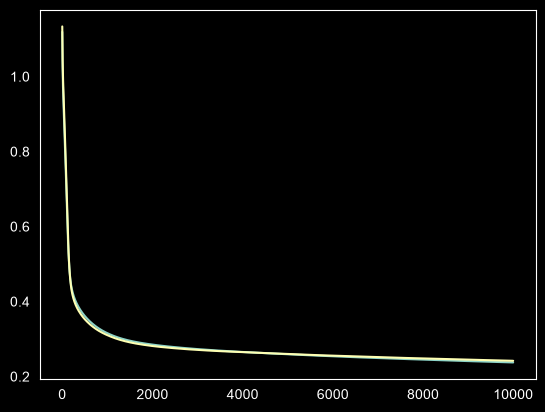

In [21]:
plt.plot(list(range(n_epochs)), train_loss)
plt.plot(list(range(n_epochs)), val_loss)
plt.grid()
plt.show()

In [22]:
with torch.no_grad():
    y_test_pred = model(X_test)
    loss_test = mse(y_test_pred, y_test)
loss_test

tensor(0.2508, device='cuda:0', dtype=torch.float64)

### Save Model - Weights & Arch

In [23]:
file_name = "models/my_model1.pt"
torch.save(model, file_name)

### Load Model - Weights & Arch

In [24]:
file_name = "models/my_model1.pt"
loaded_model = torch.load(file_name, weights_only=False)
loaded_model

Sequential(
  (0): Linear(in_features=8, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=40, bias=True)
  (3): ReLU()
  (4): Linear(in_features=40, out_features=1, bias=True)
)

In [25]:
loaded_model.eval()
with torch.no_grad():
    y_test_pred = loaded_model(X_test)
    loss_test = mse(y_test_pred, y_test)
loss_test

tensor(0.2508, device='cuda:0', dtype=torch.float64)

### Save Weights only Model

In [26]:
model.state_dict()

OrderedDict([('0.weight',
              tensor([[-1.6919e-01, -1.9282e-01,  1.1776e-01,  1.7522e-02,  1.8708e-01,
                       -1.9880e-01,  1.7486e-01,  3.0357e-01],
                      [-1.9248e-01,  4.7819e-02,  2.4017e-01,  1.2187e-01,  5.0156e-02,
                       -5.4398e-01,  3.1949e-01, -1.0699e-01],
                      [ 1.6853e-01, -3.2854e-01, -3.4548e-02, -2.7056e-03, -3.5599e-01,
                        2.1146e-01,  1.5796e-01, -2.7282e-01],
                      [ 1.7120e-02,  1.3857e-01, -2.3252e-01,  2.9931e-01, -5.7650e-02,
                        1.2279e-01,  2.5457e-01,  2.3215e-01],
                      [-2.5422e-01, -1.0215e-01, -4.7021e-02, -9.2389e-02,  1.1855e-01,
                       -6.5102e-02, -2.8971e-01,  2.7612e-01],
                      [-4.0032e-01,  2.2872e-01, -3.8722e-02,  4.0540e-01, -3.7075e-01,
                       -1.0880e-01,  1.2973e-01, -2.0749e-01],
                      [ 3.7545e-01,  9.5898e-02,  1.1689e-01, -2.255

In [27]:
file_name = "models/my_model1_weights.pt"
torch.save(model.state_dict(), file_name)

### Load Weights only Model

In [28]:
new_model = nn.Sequential(nn.Linear(n_features, 50, device=device, dtype=torch.float64), nn.ReLU(),
                      nn.Linear(50, 40, device=device, dtype=torch.float64), nn.ReLU(),
                      nn.Linear(40, 1, device=device, dtype=torch.float64))
new_model

Sequential(
  (0): Linear(in_features=8, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=40, bias=True)
  (3): ReLU()
  (4): Linear(in_features=40, out_features=1, bias=True)
)

In [29]:
file_name = "models/my_model1_weights.pt"
loaded_weights = torch.load(file_name, weights_only=True)
loaded_weights

OrderedDict([('0.weight',
              tensor([[-1.6919e-01, -1.9282e-01,  1.1776e-01,  1.7522e-02,  1.8708e-01,
                       -1.9880e-01,  1.7486e-01,  3.0357e-01],
                      [-1.9248e-01,  4.7819e-02,  2.4017e-01,  1.2187e-01,  5.0156e-02,
                       -5.4398e-01,  3.1949e-01, -1.0699e-01],
                      [ 1.6853e-01, -3.2854e-01, -3.4548e-02, -2.7056e-03, -3.5599e-01,
                        2.1146e-01,  1.5796e-01, -2.7282e-01],
                      [ 1.7120e-02,  1.3857e-01, -2.3252e-01,  2.9931e-01, -5.7650e-02,
                        1.2279e-01,  2.5457e-01,  2.3215e-01],
                      [-2.5422e-01, -1.0215e-01, -4.7021e-02, -9.2389e-02,  1.1855e-01,
                       -6.5102e-02, -2.8971e-01,  2.7612e-01],
                      [-4.0032e-01,  2.2872e-01, -3.8722e-02,  4.0540e-01, -3.7075e-01,
                       -1.0880e-01,  1.2973e-01, -2.0749e-01],
                      [ 3.7545e-01,  9.5898e-02,  1.1689e-01, -2.255

In [30]:
new_model.load_state_dict(loaded_weights)
new_model.eval()
with torch.no_grad():
    y_test_pred = loaded_model(X_test)
    loss_test = mse(y_test_pred, y_test)
loss_test

tensor(0.2508, device='cuda:0', dtype=torch.float64)

### Save Model Weights & Metadata

In [31]:
model_weights = model.state_dict()

In [32]:
model_arch = {"0": nn.Linear(n_features, 50, device=device, dtype=torch.float64),
              "1": nn.ReLU(),
              "2": nn.Linear(50, 40, device=device, dtype=torch.float64),
              "3": nn.ReLU(),
              "4": nn.Linear(40, 1, device=device, dtype=torch.float64)}
model_arch

{'0': Linear(in_features=8, out_features=50, bias=True),
 '1': ReLU(),
 '2': Linear(in_features=50, out_features=40, bias=True),
 '3': ReLU(),
 '4': Linear(in_features=40, out_features=1, bias=True)}

In [33]:
model_data = {"model_state_dict": model_weights, "model_arch": model_arch}
file_name = "models/my_model1_weight_metadata.pt"
torch.save(model_data, file_name)

### Load Model Weights & Metadata

In [34]:
file_name = "models/my_model1_weight_metadata.pt"
loaded_data = torch.load(file_name, weights_only=False)
loaded_data

{'model_state_dict': OrderedDict([('0.weight',
               tensor([[-1.6919e-01, -1.9282e-01,  1.1776e-01,  1.7522e-02,  1.8708e-01,
                        -1.9880e-01,  1.7486e-01,  3.0357e-01],
                       [-1.9248e-01,  4.7819e-02,  2.4017e-01,  1.2187e-01,  5.0156e-02,
                        -5.4398e-01,  3.1949e-01, -1.0699e-01],
                       [ 1.6853e-01, -3.2854e-01, -3.4548e-02, -2.7056e-03, -3.5599e-01,
                         2.1146e-01,  1.5796e-01, -2.7282e-01],
                       [ 1.7120e-02,  1.3857e-01, -2.3252e-01,  2.9931e-01, -5.7650e-02,
                         1.2279e-01,  2.5457e-01,  2.3215e-01],
                       [-2.5422e-01, -1.0215e-01, -4.7021e-02, -9.2389e-02,  1.1855e-01,
                        -6.5102e-02, -2.8971e-01,  2.7612e-01],
                       [-4.0032e-01,  2.2872e-01, -3.8722e-02,  4.0540e-01, -3.7075e-01,
                        -1.0880e-01,  1.2973e-01, -2.0749e-01],
                       [ 3.7545e-01

In [35]:
loaded_data.keys()

dict_keys(['model_state_dict', 'model_arch'])

In [36]:
loaded_weights = loaded_data["model_state_dict"]
loaded_arch = loaded_data["model_arch"]
loaded_arch

{'0': Linear(in_features=8, out_features=50, bias=True),
 '1': ReLU(),
 '2': Linear(in_features=50, out_features=40, bias=True),
 '3': ReLU(),
 '4': Linear(in_features=40, out_features=1, bias=True)}

In [37]:
from collections import OrderedDict
OrderedDict(loaded_arch)

OrderedDict([('0', Linear(in_features=8, out_features=50, bias=True)),
             ('1', ReLU()),
             ('2', Linear(in_features=50, out_features=40, bias=True)),
             ('3', ReLU()),
             ('4', Linear(in_features=40, out_features=1, bias=True))])

In [38]:
meta_model = nn.Sequential(OrderedDict(loaded_arch))
meta_model

Sequential(
  (0): Linear(in_features=8, out_features=50, bias=True)
  (1): ReLU()
  (2): Linear(in_features=50, out_features=40, bias=True)
  (3): ReLU()
  (4): Linear(in_features=40, out_features=1, bias=True)
)

In [39]:
meta_model.load_state_dict(loaded_weights)
meta_model.eval()
with torch.no_grad():
    y_test_pred = meta_model(X_test)
    loss_test = mse(y_test_pred, y_test)
loss_test

tensor(0.2508, device='cuda:0', dtype=torch.float64)

end